In [2]:
import json
import os

os.chdir("..")

In [3]:
from cluster_intrep_repo.utils import DOMAIN_PHRASES

In [4]:
from pathlib import Path

cur_dir = Path(".").absolute()


existing_runs = []

for i in range(1, 16):
    prompt_dir = cur_dir / Path(f"./cot-planning/results/blocksworld_mystery_{i}/qwq-32b-steered-full-0-greedy/")
    if prompt_dir.exists():
        existing_runs.append(i)
    

In [5]:
existing_runs

[1, 2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 14, 15]

In [6]:
from pathlib import Path

cur_dir = Path(".").absolute()


def load_dataset_from_file(domain_name, task_name, model_name):
    prompt_dir = cur_dir / Path(f"./cot-planning/results/{domain_name}/{model_name}/")
    with open(prompt_dir / f"{task_name}.json", 'r') as file:
        return json.load(file)

In [7]:
def get_eval_results(i: int):
    task_name = "plan_generation_po"
    eval_results = [
        load_dataset_from_file(f"blocksworld_mystery_{i}", task_name, model_name)["instances"] for model_name in [
            "qwq-32b-steered-full-0-greedy", "qwq-32b-steered-full-il-60-greedy"
        ]
    ]
    eval_results = [{x["dataset_idx"]: x for x in er} for er in eval_results]
    
    total_correct = [
        sum(x.get("llm_correct", False) for x in er.values()) for er in eval_results
    ]
    
    return total_correct[1] - total_correct[0]

In [8]:
eval_results = {
    f"mystery_{i}": get_eval_results(i) for i in existing_runs
}

In [9]:
eval_results

{'mystery_1': 5,
 'mystery_2': -3,
 'mystery_3': 5,
 'mystery_4': 4,
 'mystery_5': 2,
 'mystery_6': -4,
 'mystery_7': -1,
 'mystery_9': -5,
 'mystery_10': 6,
 'mystery_12': 0,
 'mystery_13': 5,
 'mystery_14': -5,
 'mystery_15': 7}

In [10]:
representations = {}

for i in existing_runs:
    with open(f"mystery_representations_greedy/mystery_{i}/mean_reprs_mystery_{i}.json") as f:
        representations[f"mystery_{i}"] = json.load(f)

In [11]:
representations["mystery_1"].keys()

dict_keys(['mean_reprs', 'mean_domain', 'mean_actions', 'mean_predicates'])

In [ ]:
import numpy as np

action_reprs = {
    k: {
        kk: np.array(vv) - np.array(v["mean_actions"]) for kk, vv in v["mean_reprs"].items() if kk in DOMAIN_PHRASES[k]["actions"].values()
    } for k, v in representations.items()
}

predicate_reprs = {
    k: {
        kk: np.array(vv) - np.array(v["mean_predicates"]) for kk, vv in v["mean_reprs"].items() if kk in DOMAIN_PHRASES[k]["predicates"].values()
    } for k, v in representations.items()
}

In [13]:
reverse_phrases = {
    k: {kk: {
        vvv: kkk for kkk, vvv in vv.items()
    } for kk, vv in v.items() }
    for k, v in DOMAIN_PHRASES.items()
}

In [14]:
predicates = list(reverse_phrases["mystery_3"]["predicates"].values())
actions = list(reverse_phrases["mystery_3"]["actions"].values())

In [15]:
action_reprs = {
    k: {
        reverse_phrases[k]["actions"][kk]: vv for kk, vv in v.items()
    } for k, v in action_reprs.items()
}

predicate_reprs = {
    k: {
        reverse_phrases[k]["predicates"][kk]: vv for kk, vv in v.items()
    } for k, v in predicate_reprs.items()
}

In [16]:
mean_action_reprs = {
    action: np.mean(
        np.stack(
            [action_reprs[m][action] for m in action_reprs]
        ), axis=0
    ) for action in actions
}

In [17]:
mean_predicate_reprs = {
    pr: np.mean(
        np.stack(
            [predicate_reprs[m][pr] for m in predicate_reprs]
        ), axis=0
    ) for pr in predicates
}

In [ ]:
from pathlib import Path
for i in range(1, 16):
    path = f"mystery_representations_greedy_avg/mystery_{i}/mean_reprs_mystery_{i}.json"
    os.makedirs(Path(path).parent, exist_ok=True)
    
    reprs = {
        "mean_domain": [0] * 5120,
        "mean_actions": [0] * 5120,
        "mean_predicates": [0] * 5120,
        "mean_reprs": {
            DOMAIN_PHRASES[f"mystery_{i}"]["actions"][action]: mean_action_reprs[action].tolist() for action in actions
        }
    }
    
    reprs["mean_reprs"].update({
        DOMAIN_PHRASES[f"mystery_{i}"]["predicates"][predicate]: mean_predicate_reprs[predicate].tolist() for predicate in predicates
    })
    
    with open(path, "w") as f:
        json.dump(reprs, f)

: 

In [26]:
action_reprs

{'mystery_1': {'attack': array([ 0.04089355, -0.66943359, -0.56433105, ..., -1.66210938,
         -0.12866211,  0.43530273]),
  'succumb': array([ 0.27325439, -0.40234375,  0.73327637, ...,  3.515625  ,
         -0.07104492,  0.25537109]),
  'overcome': array([ 0.31750488,  0.88720703, -0.28234863, ..., -2.46679688,
          0.12426758,  0.04345703]),
  'feast': array([-0.63146973,  0.18505859,  0.11340332, ...,  0.60546875,
          0.07568359, -0.734375  ])},
 'mystery_2': {'attack': array([-0.13671875, -0.01416016, -0.19561768, ...,  0.99609375,
         -0.05932617,  0.41186523]),
  'succumb': array([-0.25585938, -0.29736328,  0.11288452, ..., -3.92480469,
          0.29803467, -0.28125   ]),
  'overcome': array([ 0.08837891,  0.57336426,  0.11129761, ...,  2.96875   ,
         -0.03710938, -0.15429688]),
  'feast': array([ 0.30517578, -0.26220703, -0.02862549, ..., -0.046875  ,
         -0.20117188,  0.02392578])},
 'mystery_3': {'attack': array([ 0.35839844, -0.18609619, -0.254

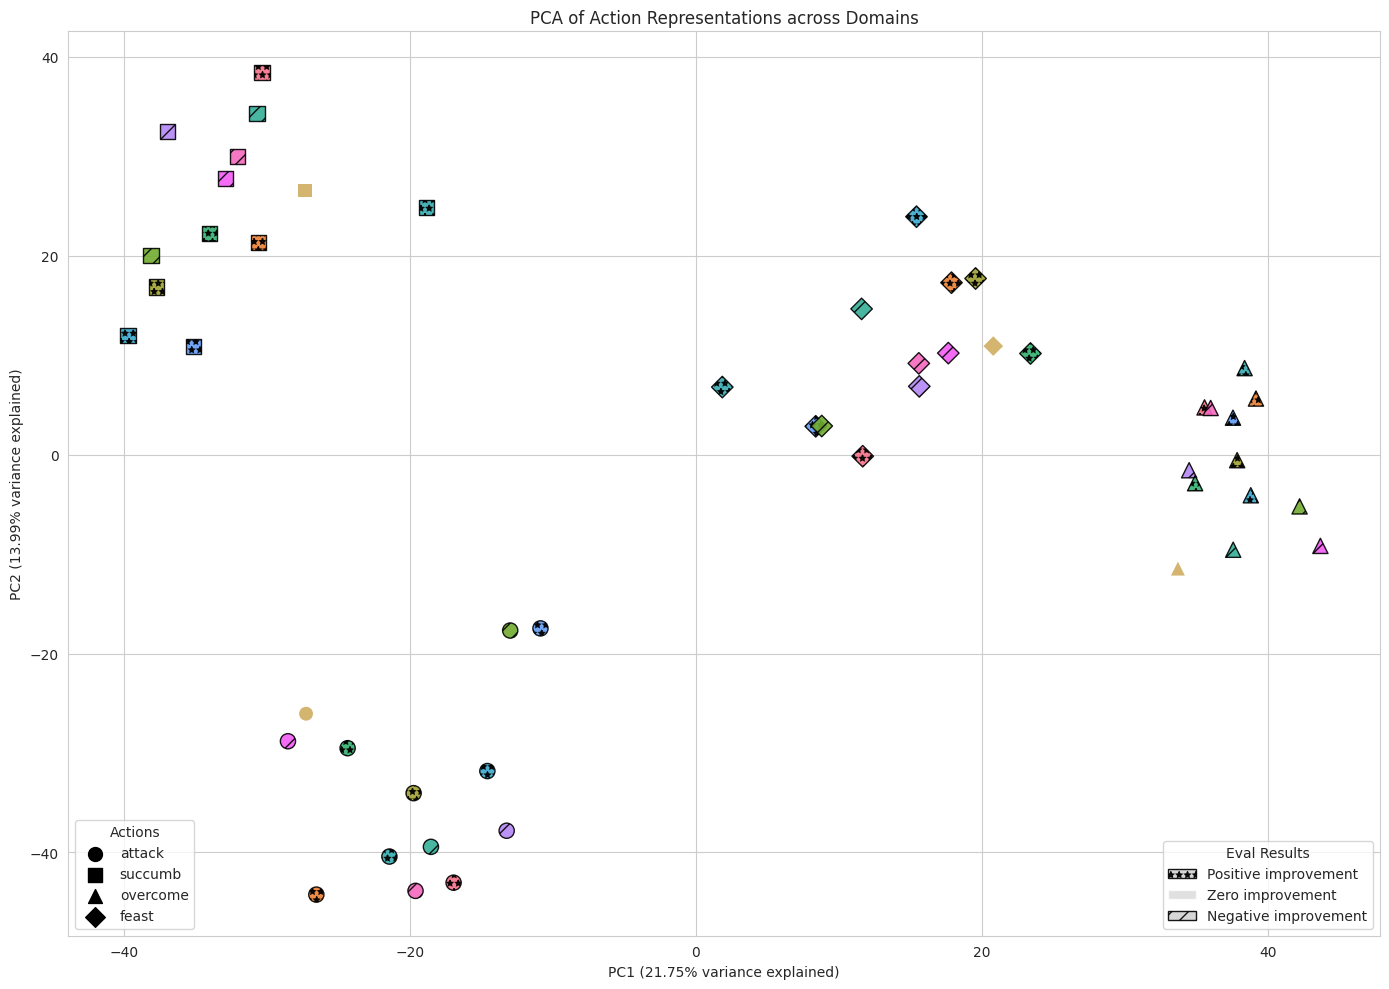

In [31]:
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Create arrays for PCA
X = []
action_labels = []
domain_labels = []

for domain, actions in action_reprs.items():
    for action, repr_vector in actions.items():
        X.append(repr_vector)
        action_labels.append(action)
        domain_labels.append(domain)

# Perform PCA
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X)

# Create a DataFrame for easier plotting
df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Action': action_labels,
    'Domain': domain_labels
})

# Add eval_results category to the dataframe
df['Eval_Result'] = df['Domain'].map(lambda x: 'Positive' if eval_results[x] > 0 
                                   else ('Zero' if eval_results[x] == 0 else 'Negative'))

# Set up the plot
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

# Define markers for different actions
markers = {'attack': 'o', 'succumb': 's', 'overcome': '^', 'feast': 'D'}
# markers = {'planet': 'o', 'province': 's', 'harmony': '^', 'craves': 'D', 'pain': 'X'}

# Create a color palette for the domains
palette = sns.color_palette("husl", len(df['Domain'].unique()))
domain_colors = {domain: color for domain, color in zip(
    sorted(df['Domain'].unique()), palette)}

# Define hatches/patterns based on eval_results
hatch_patterns = {'Positive': '**', 'Zero': '', 'Negative': '//'}
sizes = {'Positive': 120, 'Zero': 100, 'Negative': 120}
alphas = {'Positive': 0.9, 'Zero': 0.7, 'Negative': 0.9}

# Plot each action type with a different marker
for action, marker in markers.items():
    subset = df[df['Action'] == action]
    for domain in subset['Domain'].unique():
        domain_subset = subset[subset['Domain'] == domain]
        eval_cat = domain_subset['Eval_Result'].iloc[0]
        
        plt.scatter(
            domain_subset['PC1'],
            domain_subset['PC2'],
            marker=marker,
            color=domain_colors[domain],
            s=sizes[eval_cat],
            label=f"{domain} - {action}" if action == list(markers.keys())[0] else None,
            alpha=alphas[eval_cat],
            edgecolor='black' if eval_cat != 'Zero' else None,
            linewidth=1 if eval_cat != 'Zero' else 0,
            hatch=hatch_patterns[eval_cat]
        )

# Add action labels to the legend separately
for action, marker in markers.items():
    plt.scatter([], [], marker=marker, color='black', label=action, s=100)

# Variance explained
explained_variance = pca.explained_variance_ratio_
plt.xlabel(f'PC1 ({explained_variance[0]:.2%} variance explained)')
plt.ylabel(f'PC2 ({explained_variance[1]:.2%} variance explained)')
plt.title('PCA of Action Representations across Domains')

# Create legend with only domain colors
handles, labels = plt.gca().get_legend_handles_labels()
domain_legend = plt.legend(handles[:len(domain_colors)], labels[:len(domain_colors)],
                           loc='upper left', title='Domains')
# plt.gca().add_artist(domain_legend)

# Create second legend for action markers
action_handles = handles[len(domain_colors):]
action_labels = labels[len(domain_colors):]
actions_legend = plt.legend(action_handles, action_labels, loc='lower left', title='Actions')
plt.gca().add_artist(actions_legend)

# Create a third legend for eval_results patterns
eval_handles = []
for cat, pattern in hatch_patterns.items():
    color = 'lightgray'
    patch = mpatches.Patch(facecolor=color, alpha=alphas[cat], 
                           hatch=pattern, edgecolor='black' if cat != 'Zero' else None, 
                           label=f"{cat} improvement")
    eval_handles.append(patch)

plt.legend(handles=eval_handles, title='Eval Results', 
           loc='lower right', bbox_to_anchor=(1.0, 0))

plt.tight_layout()
plt.show()